<a href="https://colab.research.google.com/github/hariomlohardev/micrograd-hk/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# micrograd_hk — Demo Notebook

This notebook installs `micrograd_hk` from PyPI, builds a small MLP, and trains it
using both **Adam** and the custom **Adam-M** optimizer on a toy heart-disease-style
dataset, then plots a convergence comparison.

Run this top to bottom on Google Colab or locally.

## 1. Install the package

In [1]:
!pip install -q micrograd_hk


## 2. Imports

In [2]:
import copy
import numpy as np
import matplotlib.pyplot as plt

from micrograd_hk import Value, DenseLayer, MLP, Trainer


## 3. Dataset

Toy features: `[Age, BloodPressure, MaxHeartRate]` (normalized 0.0–1.0), with a
binary target label (`1.0` / `-1.0`).

In [3]:
xs = [
    [0.43, 0.39, 0.61], [0.63, 0.67, 0.54], [0.48, 0.76, 0.55], [0.45, 0.64, 0.73], [0.23, 0.24, 0.49],
    [0.88, 0.49, 0.83], [0.56, 0.41, 0.39], [0.40, 0.53, 0.35], [0.49, 0.48, 0.70], [0.52, 0.26, 0.57],
    [0.85, 0.60, 0.57], [0.83, 0.44, 0.75], [0.11, 0.41, 0.61], [0.49, 0.53, 0.24], [0.22, 0.15, 0.49],
    [0.50, 0.70, 0.78], [0.15, 0.47, 0.64], [0.41, 0.52, 0.57], [0.36, 0.19, 0.63], [0.49, 0.40, 0.56],
    [0.77, 0.77, 0.58], [0.66, 0.71, 0.52], [0.34, 0.55, 0.36], [0.55, 0.79, 0.67], [0.22, 0.23, 0.50],
    [0.88, 0.70, 0.70], [0.42, 0.69, 0.65], [0.53, 0.70, 0.56], [0.58, 0.72, 0.49], [0.17, 0.22, 0.63],
    [0.70, 0.75, 0.65], [0.55, 0.56, 0.61], [0.46, 0.40, 0.83], [0.19, 0.26, 0.45], [0.49, 0.63, 0.54],
    [0.38, 0.16, 0.47], [0.65, 0.67, 0.55], [0.70, 0.74, 0.62], [0.29, 0.33, 0.52], [0.46, 0.22, 0.25],
    [0.43, 0.48, 0.22], [0.75, 0.50, 0.48], [0.54, 0.37, 0.25], [0.55, 0.68, 0.66], [0.17, 0.43, 0.60],
    [0.43, 0.50, 0.50], [0.80, 0.50, 0.58], [0.74, 0.75, 0.60], [0.71, 0.70, 0.77], [0.45, 0.59, 0.60],
    [0.22, 0.15, 0.48], [0.19, 0.49, 0.55], [0.44, 0.45, 0.60], [0.16, 0.38, 0.37], [0.21, 0.32, 0.66],
    [0.27, 0.16, 0.26], [0.73, 0.57, 0.46], [0.55, 0.58, 0.22], [0.67, 0.36, 0.47], [0.55, 0.58, 0.31],
    [0.48, 0.62, 0.81], [0.66, 0.38, 0.79], [0.51, 0.51, 0.77], [0.70, 0.51, 0.45], [0.44, 0.20, 0.67],
    [0.55, 0.44, 0.35], [0.42, 0.27, 0.46], [0.79, 0.68, 0.62], [0.26, 0.30, 0.55], [0.47, 0.44, 0.81],
    [0.12, 0.44, 0.38], [0.36, 0.44, 0.34], [0.37, 0.25, 0.46], [0.28, 0.40, 0.51], [0.54, 0.58, 0.51],
    [0.57, 0.55, 0.55], [0.66, 0.54, 0.65], [0.87, 0.38, 0.59], [0.27, 0.51, 0.65], [0.51, 0.28, 0.43],
    [0.59, 0.79, 0.46], [0.88, 0.47, 0.51], [0.70, 0.37, 0.54], [0.55, 0.35, 0.58], [0.42, 0.46, 0.70],
    [0.46, 0.34, 0.58], [0.48, 0.45, 0.55], [0.15, 0.57, 0.22], [0.42, 0.44, 0.27], [0.55, 0.41, 0.77],
    [0.62, 0.38, 0.81], [0.42, 0.40, 0.65], [0.82, 0.72, 0.82], [0.49, 0.59, 0.80], [0.22, 0.19, 0.39],
    [0.62, 0.56, 0.84], [0.59, 0.42, 0.28], [0.56, 0.59, 0.69], [0.42, 0.32, 0.38], [0.27, 0.57, 0.46],
]

ys = [
    1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, -1.0, 1.0, -1.0, 1.0, 1.0, -1.0, -1.0, -1.0,
    1.0, -1.0, 1.0, -1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, 1.0, 1.0, 1.0, 1.0, -1.0,
    1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, -1.0, 1.0, -1.0,
    1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, -1.0, 1.0, -1.0,
    1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0,
    -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0,
    1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0, -1.0,
]

xs_matrix = np.array(xs, dtype=np.float32)
ys_matrix = np.array(ys, dtype=np.float32).reshape(-1, 1)

print("xs_matrix shape:", xs_matrix.shape)
print("ys_matrix shape:", ys_matrix.shape)


xs_matrix shape: (100, 3)
ys_matrix shape: (100, 1)


## 4. Build the model

In [4]:
# 3 input features -> [8, 8, 1]
m = MLP(shape=[1, 3], nouts=[8, 8, 1])
m


## 5. Train with Adam and Adam-M

Both optimizers train on an identical, deep-copied initialization of the model so the
comparison is apples-to-apples.

In [5]:
optimizers = ['adam', 'adam_m']
all_histories = {}

for opt in optimizers:
    test_model = copy.deepcopy(m)
    loss_evaluator = Trainer(test_model, xs_matrix, ys_matrix)

    final_loss, y_pred = loss_evaluator.train(
        lr=0.01,
        iterations=3000,
        optimizer=opt,
        iter_stp=None,
        save_checkpoint=False,
    )

    all_histories[opt] = loss_evaluator.loss_history

    print(f"\n##########  {opt.upper()}  ##########")
    print(f"Final Batch MSE Loss: {final_loss:.6f}")
    print("-" * 45)

    for i in range(10):
        target_val = ys_matrix[i, 0]
        prediction_val = y_pred.data[i, 0]
        print(f"Sample {i+1:02d} | Target: {target_val:+.1f} | Prediction: {prediction_val:+.3f}")
    print(f"... and {len(ys) - 10} more samples truncated.")


Training: 100%|██████████| 3000/3000 [00:02<00:00, 1321.23iter/s, loss=0.05181]



##########  ADAM  ##########
Final Batch MSE Loss: 0.049774
---------------------------------------------
Sample 01 | Target: +1.0 | Prediction: +0.961
Sample 02 | Target: +1.0 | Prediction: +0.953
Sample 03 | Target: +1.0 | Prediction: +1.000
Sample 04 | Target: +1.0 | Prediction: +0.959
Sample 05 | Target: -1.0 | Prediction: -1.000
Sample 06 | Target: +1.0 | Prediction: +1.000
Sample 07 | Target: -1.0 | Prediction: -0.996
Sample 08 | Target: -1.0 | Prediction: -1.000
Sample 09 | Target: +1.0 | Prediction: +0.942
Sample 10 | Target: -1.0 | Prediction: -1.000
... and 90 more samples truncated.


Training: 100%|██████████| 3000/3000 [00:01<00:00, 1766.40iter/s, loss=0.01663]


##########  ADAM_M  ##########
Final Batch MSE Loss: 0.016219
---------------------------------------------
Sample 01 | Target: +1.0 | Prediction: +0.972
Sample 02 | Target: +1.0 | Prediction: +0.992
Sample 03 | Target: +1.0 | Prediction: +0.992
Sample 04 | Target: +1.0 | Prediction: +0.990
Sample 05 | Target: -1.0 | Prediction: -1.000
Sample 06 | Target: +1.0 | Prediction: +1.000
Sample 07 | Target: -1.0 | Prediction: -0.982
Sample 08 | Target: -1.0 | Prediction: -0.998
Sample 09 | Target: +1.0 | Prediction: +0.968
Sample 10 | Target: -1.0 | Prediction: -1.000
... and 90 more samples truncated.


## 6. Plot convergence comparison

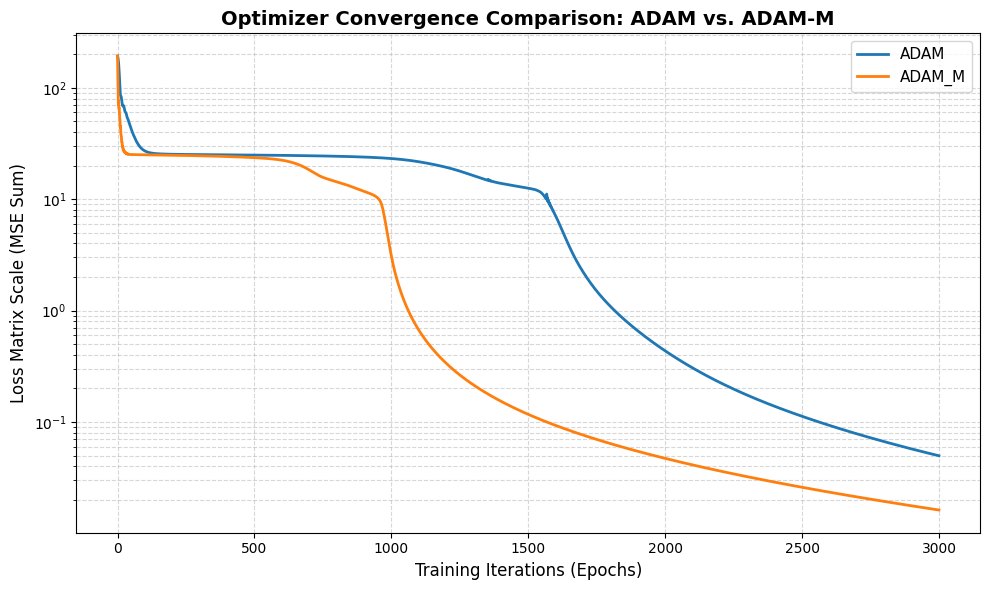

In [6]:
plt.figure(figsize=(10, 6))

for opt, history in all_histories.items():
    plt.plot(history, label=opt.upper(), linewidth=2)

plt.title("Optimizer Convergence Comparison: ADAM vs. ADAM-M", fontsize=14, fontweight='bold')
plt.xlabel("Training Iterations (Epochs)", fontsize=12)
plt.ylabel("Loss Matrix Scale (MSE Sum)", fontsize=12)
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("test1.png", dpi=150)
plt.show()


## 7. Notes

- `test1.png` (saved above) is the exact benchmark image referenced in the project's
  `README.md`.
- Set `save_checkpoint=True` in `Trainer.train(...)` to persist model weights to disk
  after training.
- See `Trainer.load_model(filepath, architecture_blueprint)` to reload a saved
  checkpoint into a fresh `MLP` of the same shape.